In [1]:
import os
import sys
from pathlib import Path

os.environ.setdefault("KERAS_BACKEND", "tensorflow")
os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/matplotlib")

PROJECT_ROOT = next(
    path
    for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "benchmark").is_dir()
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from benchmark.examples.diffusion.config import RESULT_DIR, TrainingConfig
from benchmark.examples.diffusion.results.summary_dimension_comparison import (
    LOSS_VARIANTS,
    MODEL_SETS,
    NO_MMD_SUMMARY_SPECS,
    display_gold_pmp_lowess_grid,
    display_summary_dimension_comparison,
    generate_gold_pmp_lowess_grid,
    run_comparison_pipeline,
)

INFO:bayesflow:Using backend 'tensorflow'


In [2]:
METRICS = ("l2",)
RERUN_SUFFIX = "noMMD_rerun1"
RERUN_VARIANT = "without_mmd_rerun1"
RERUN_SUMMARY_SPECS = tuple(
    (
        label,
        TrainingConfig(
            summary_multiplier=config.summary_multiplier,
            summary_base_distribution=None,
            run_suffix=RERUN_SUFFIX,
        ),
    )
    for label, config in NO_MMD_SUMMARY_SPECS
)
LOSS_VARIANTS[RERUN_VARIANT] = (
    "Without MMD loss (rerun1)",
    RERUN_SUMMARY_SPECS,
)

OUTPUT_ROOT = RESULT_DIR / "plots" / "summary_diagnostics_noMMD_rerun1"

all_l2 /Users/yimingzang/Documents/Project/benchmark2/benchmark/examples/diffusion/results/plots/summary_diagnostics_noMMD_rerun1/all/l2


## Simulated datasets

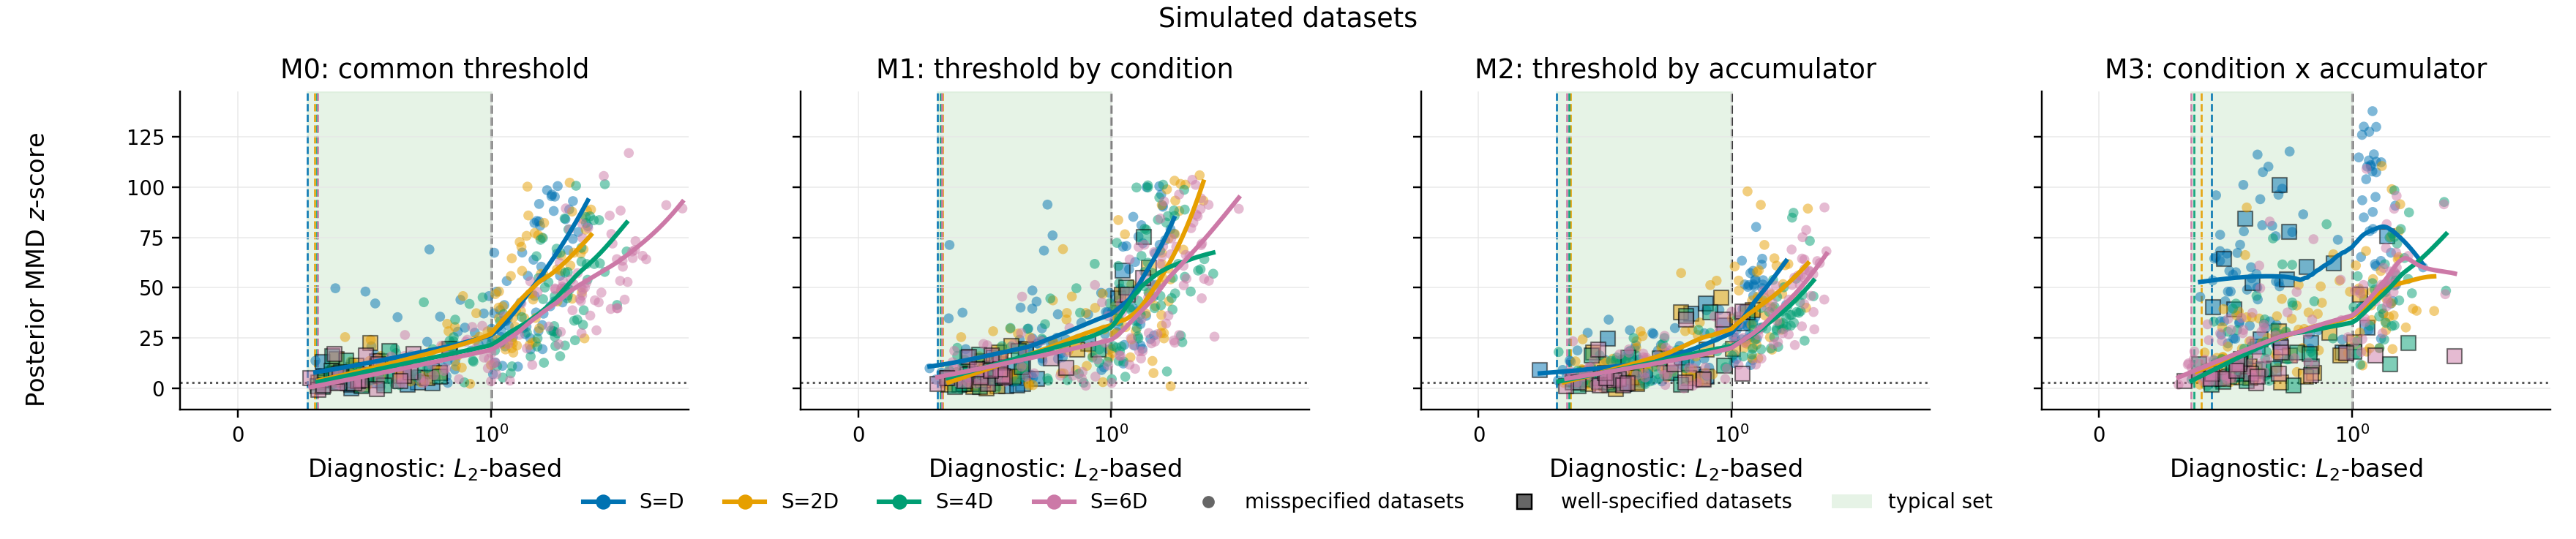

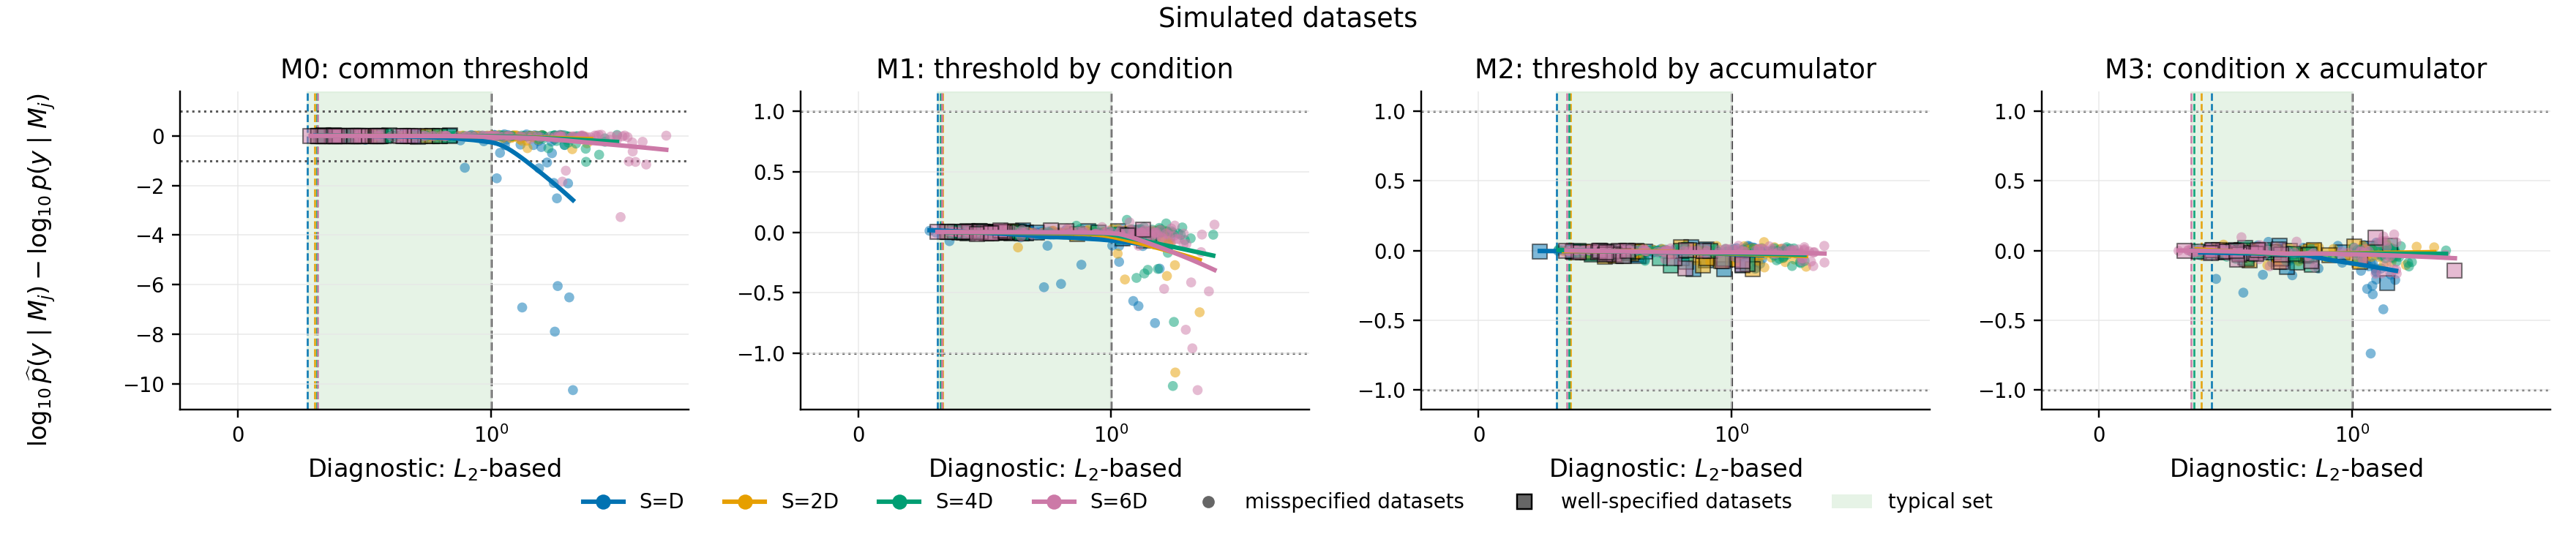

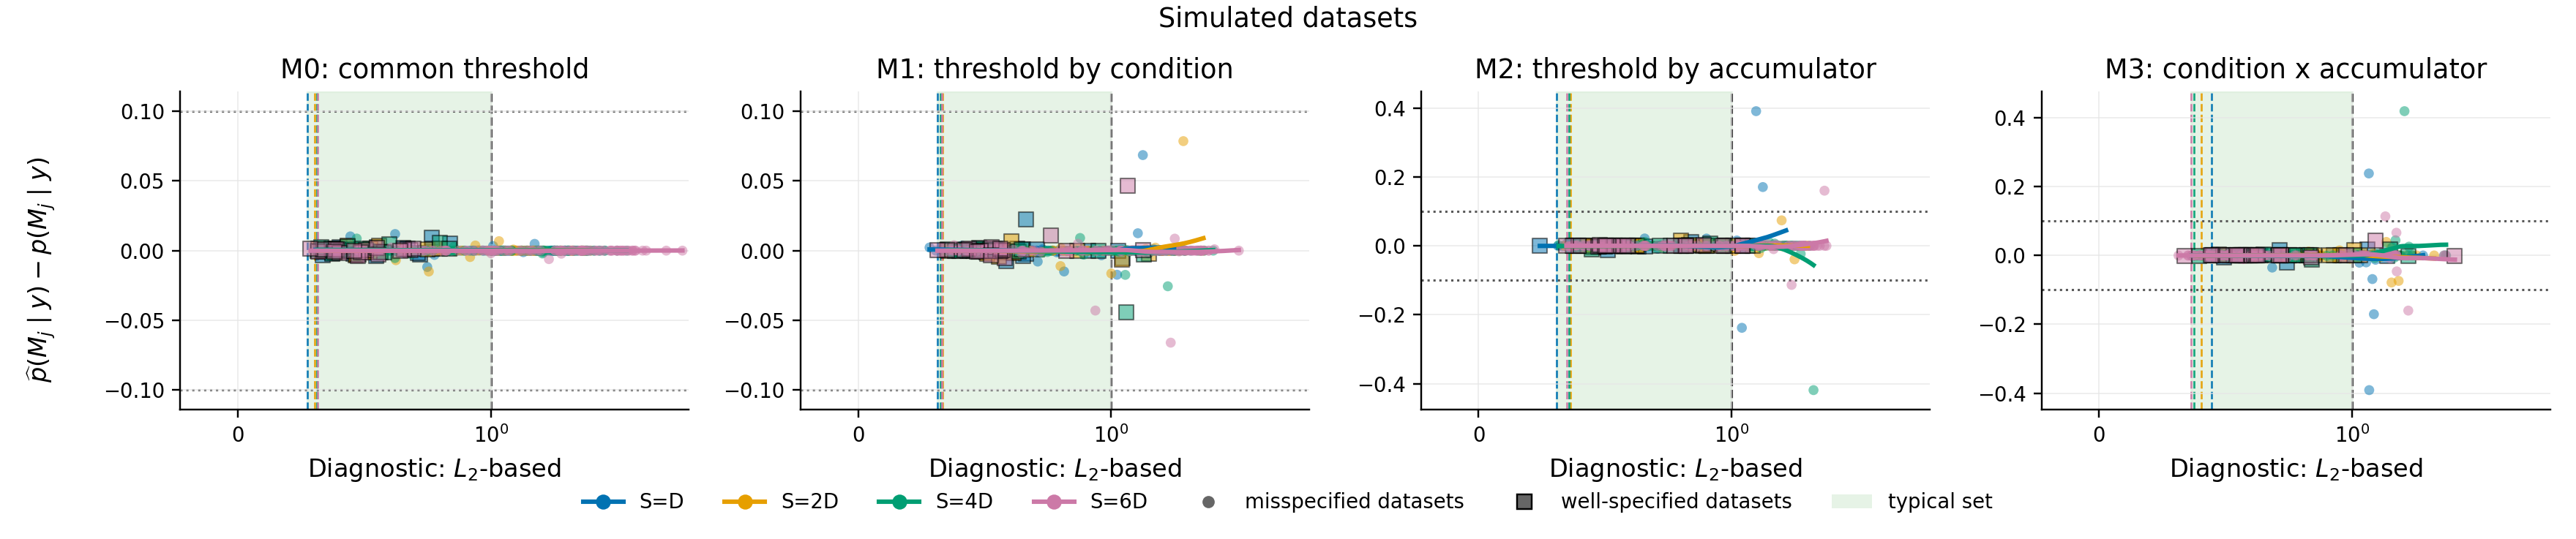

## Empirical datasets

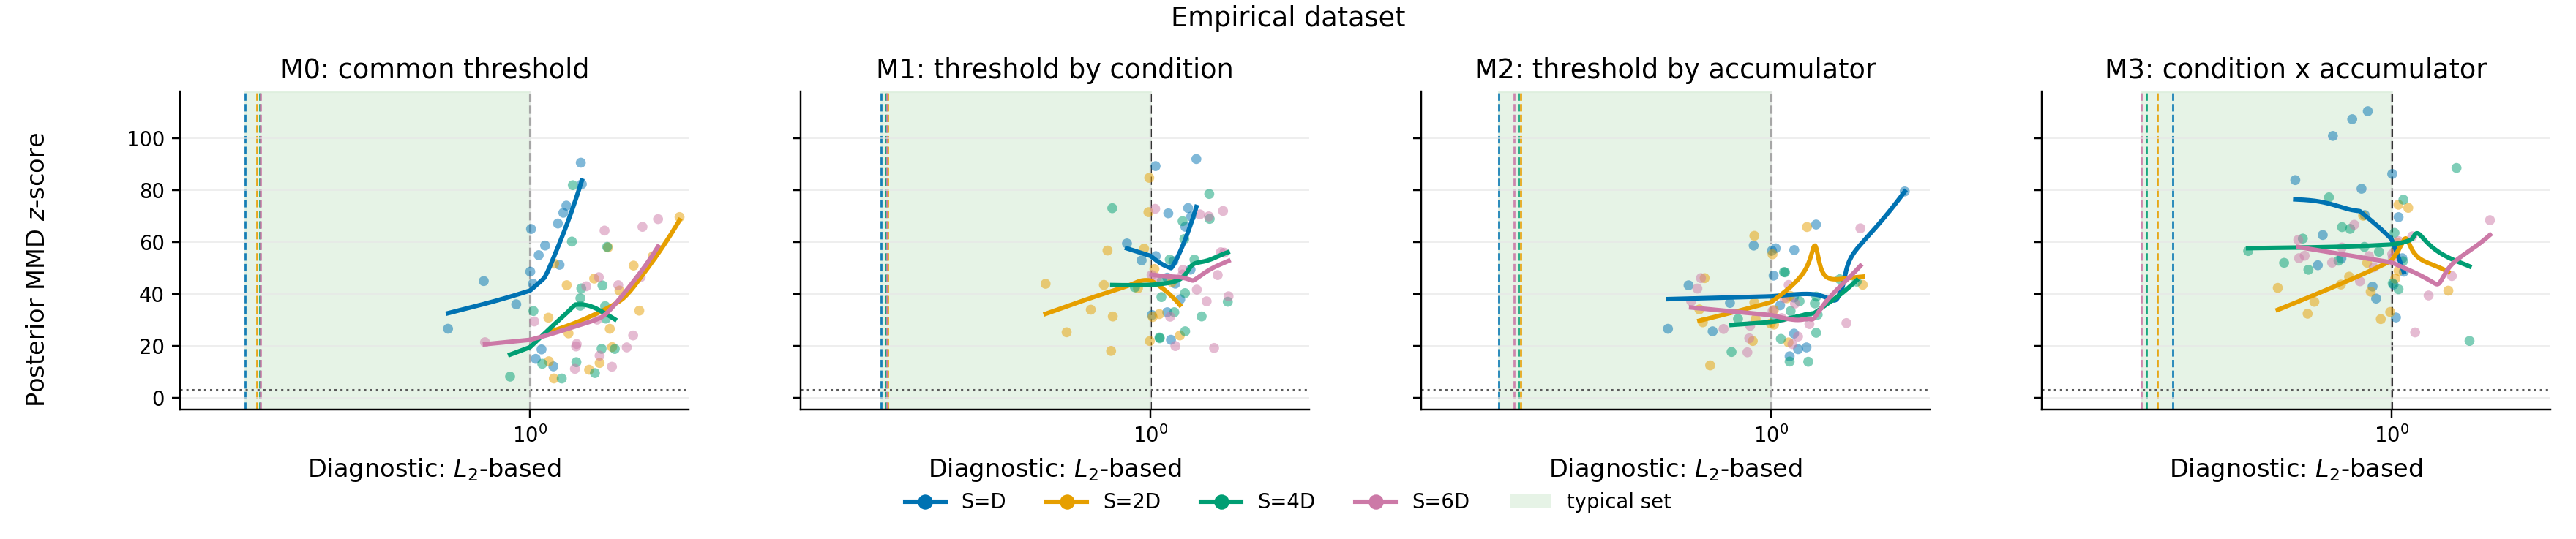

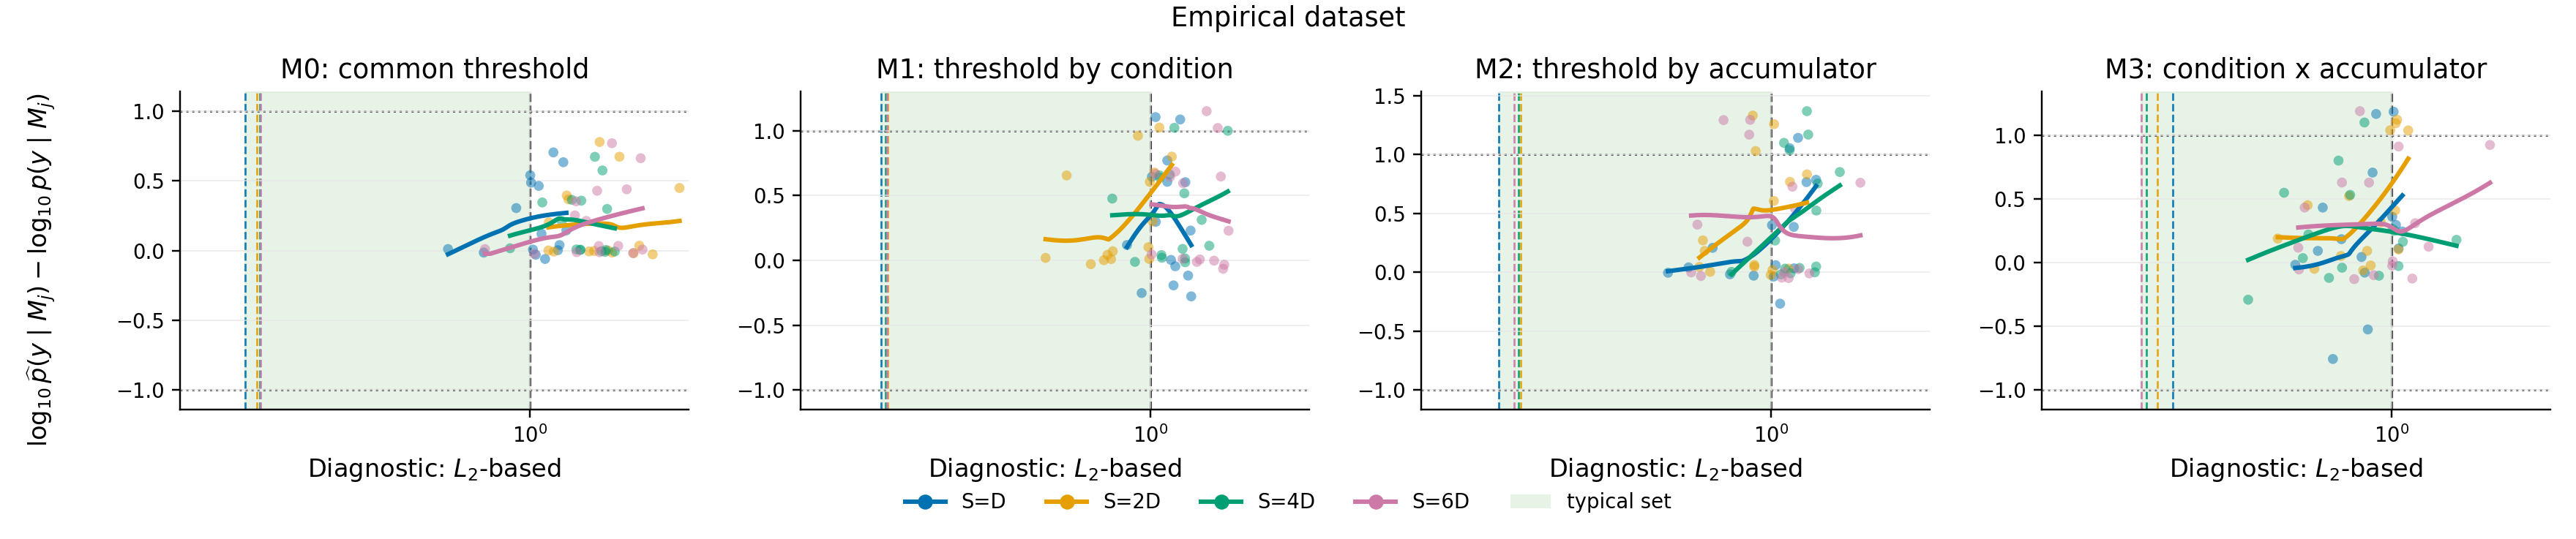

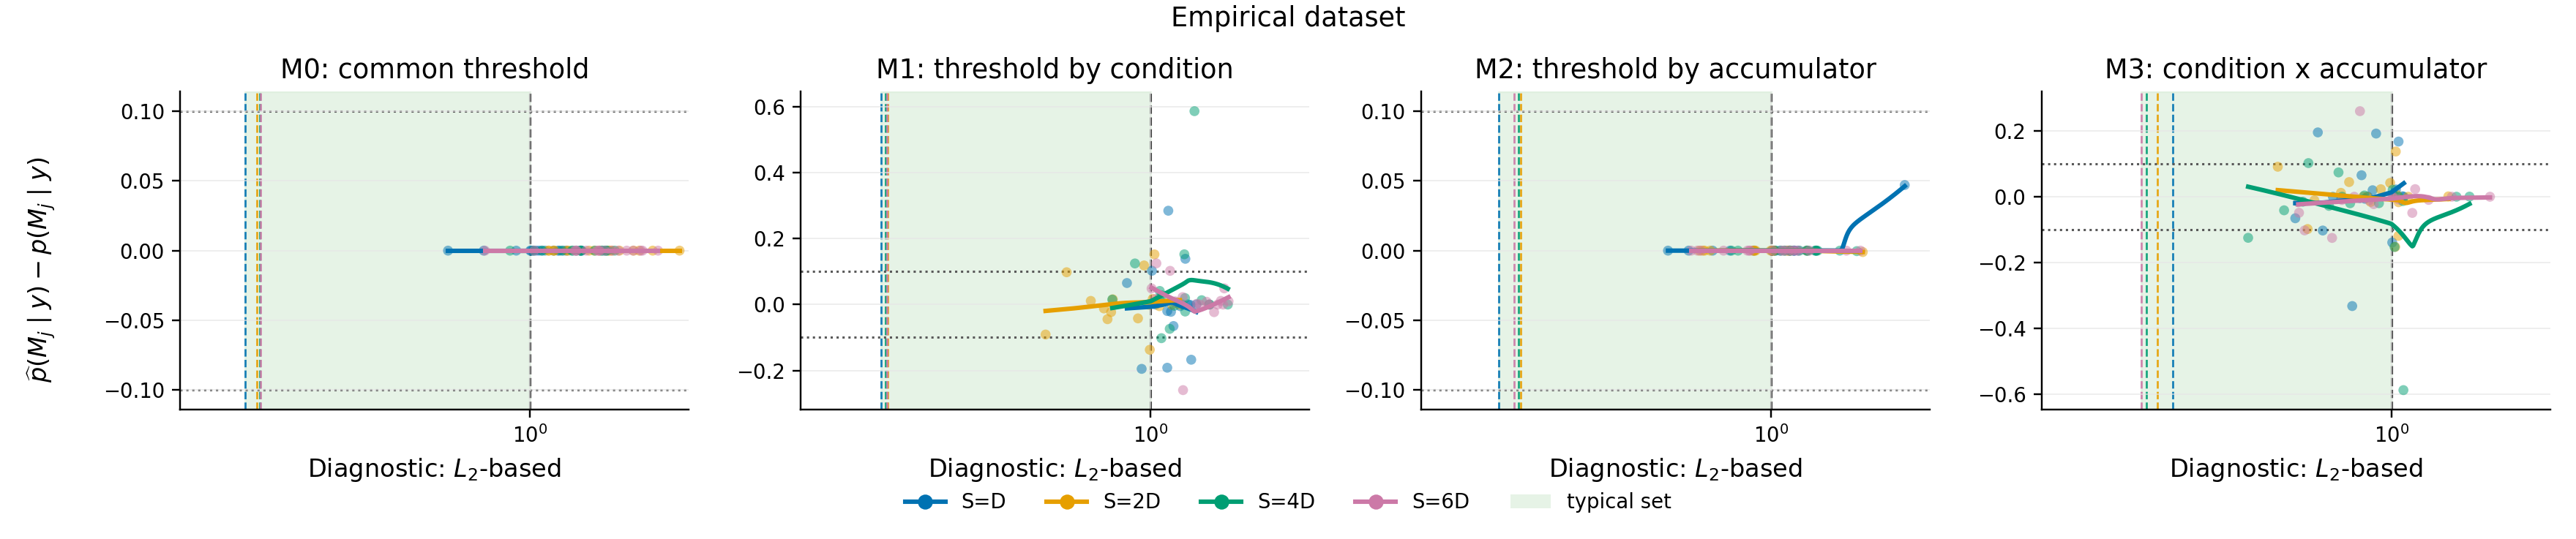

m1_m3_l2 /Users/yimingzang/Documents/Project/benchmark2/benchmark/examples/diffusion/results/plots/summary_diagnostics_noMMD_rerun1/m1_m3/l2


## Simulated datasets

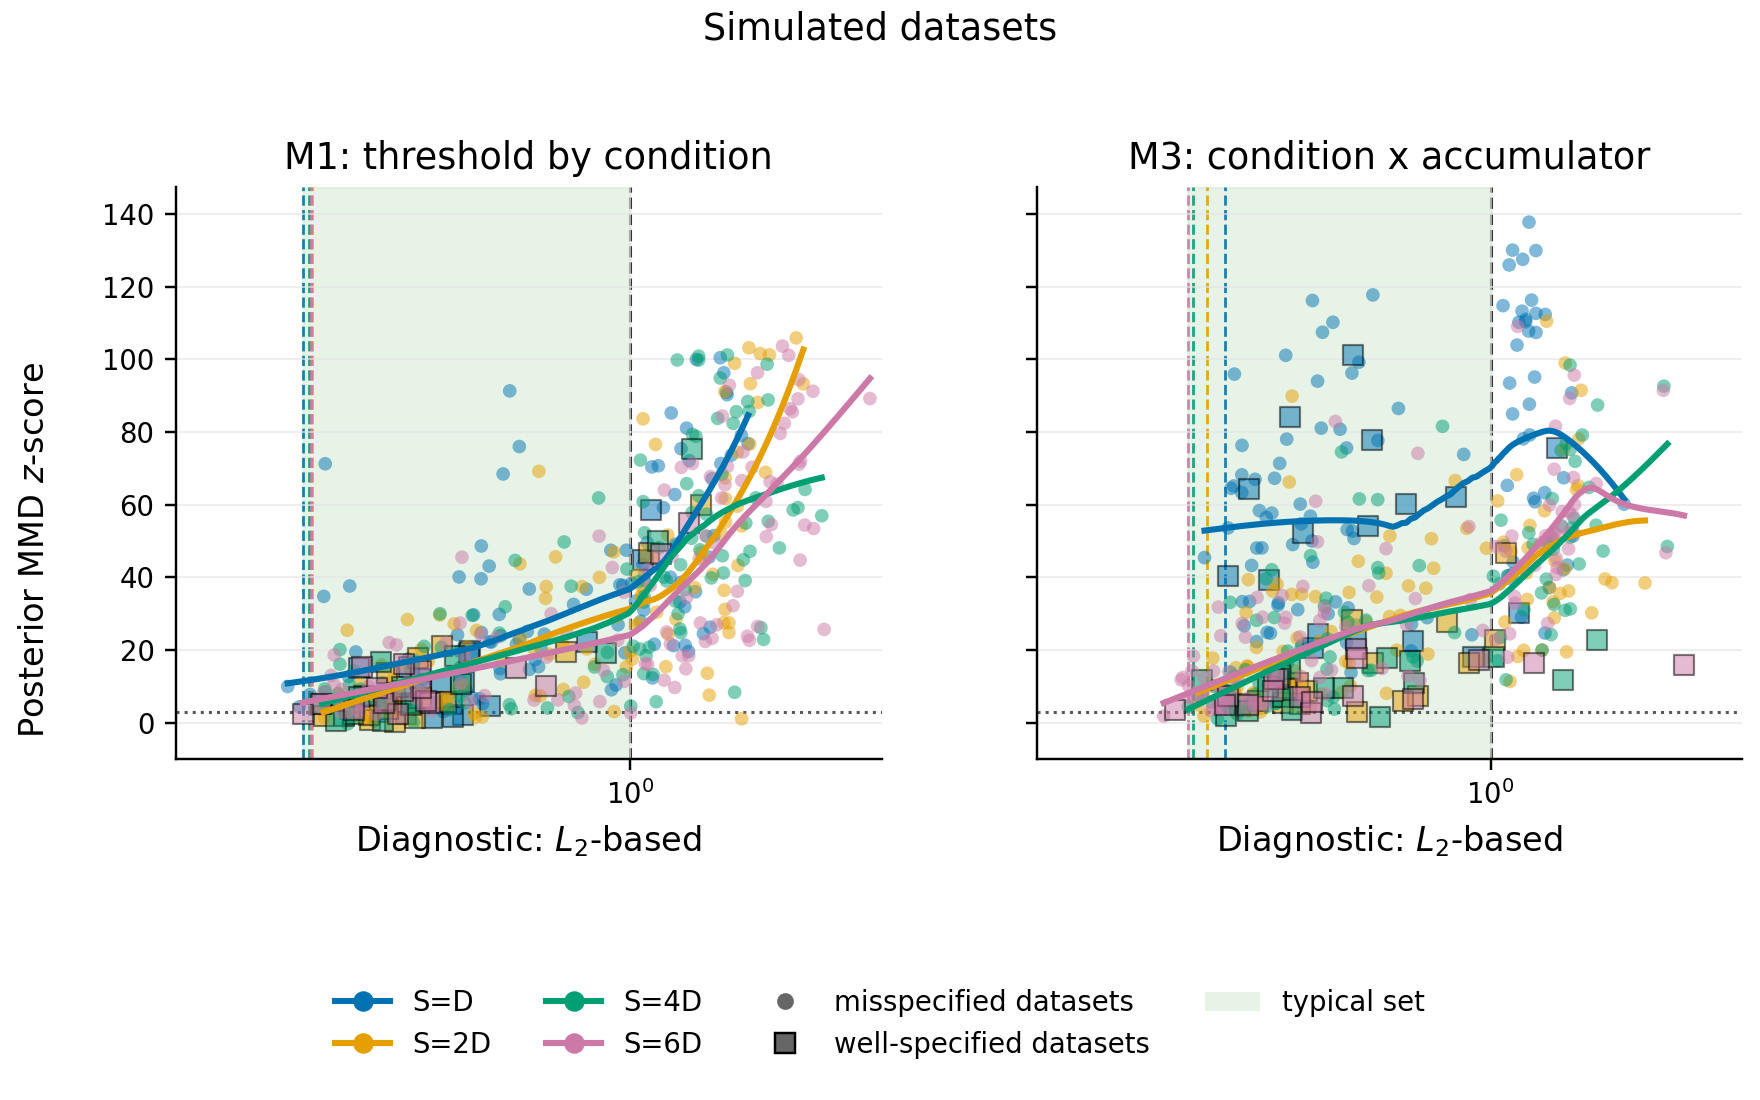

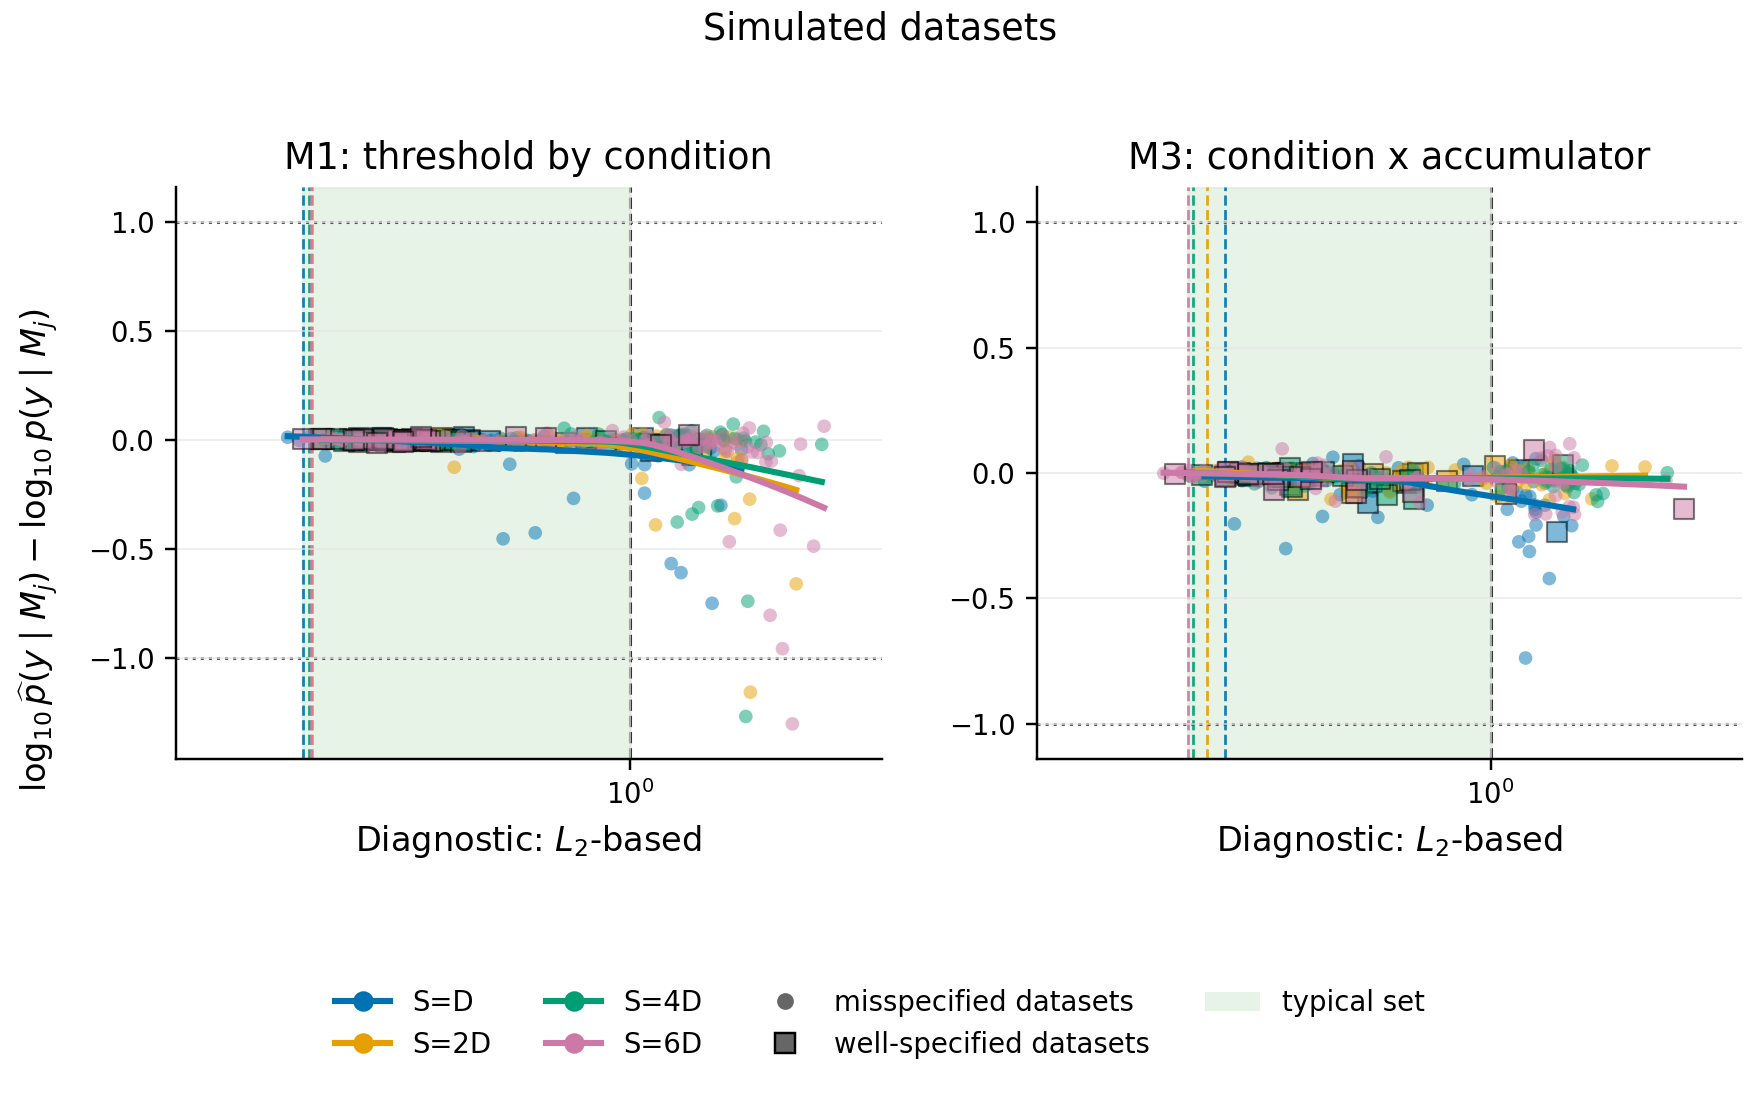

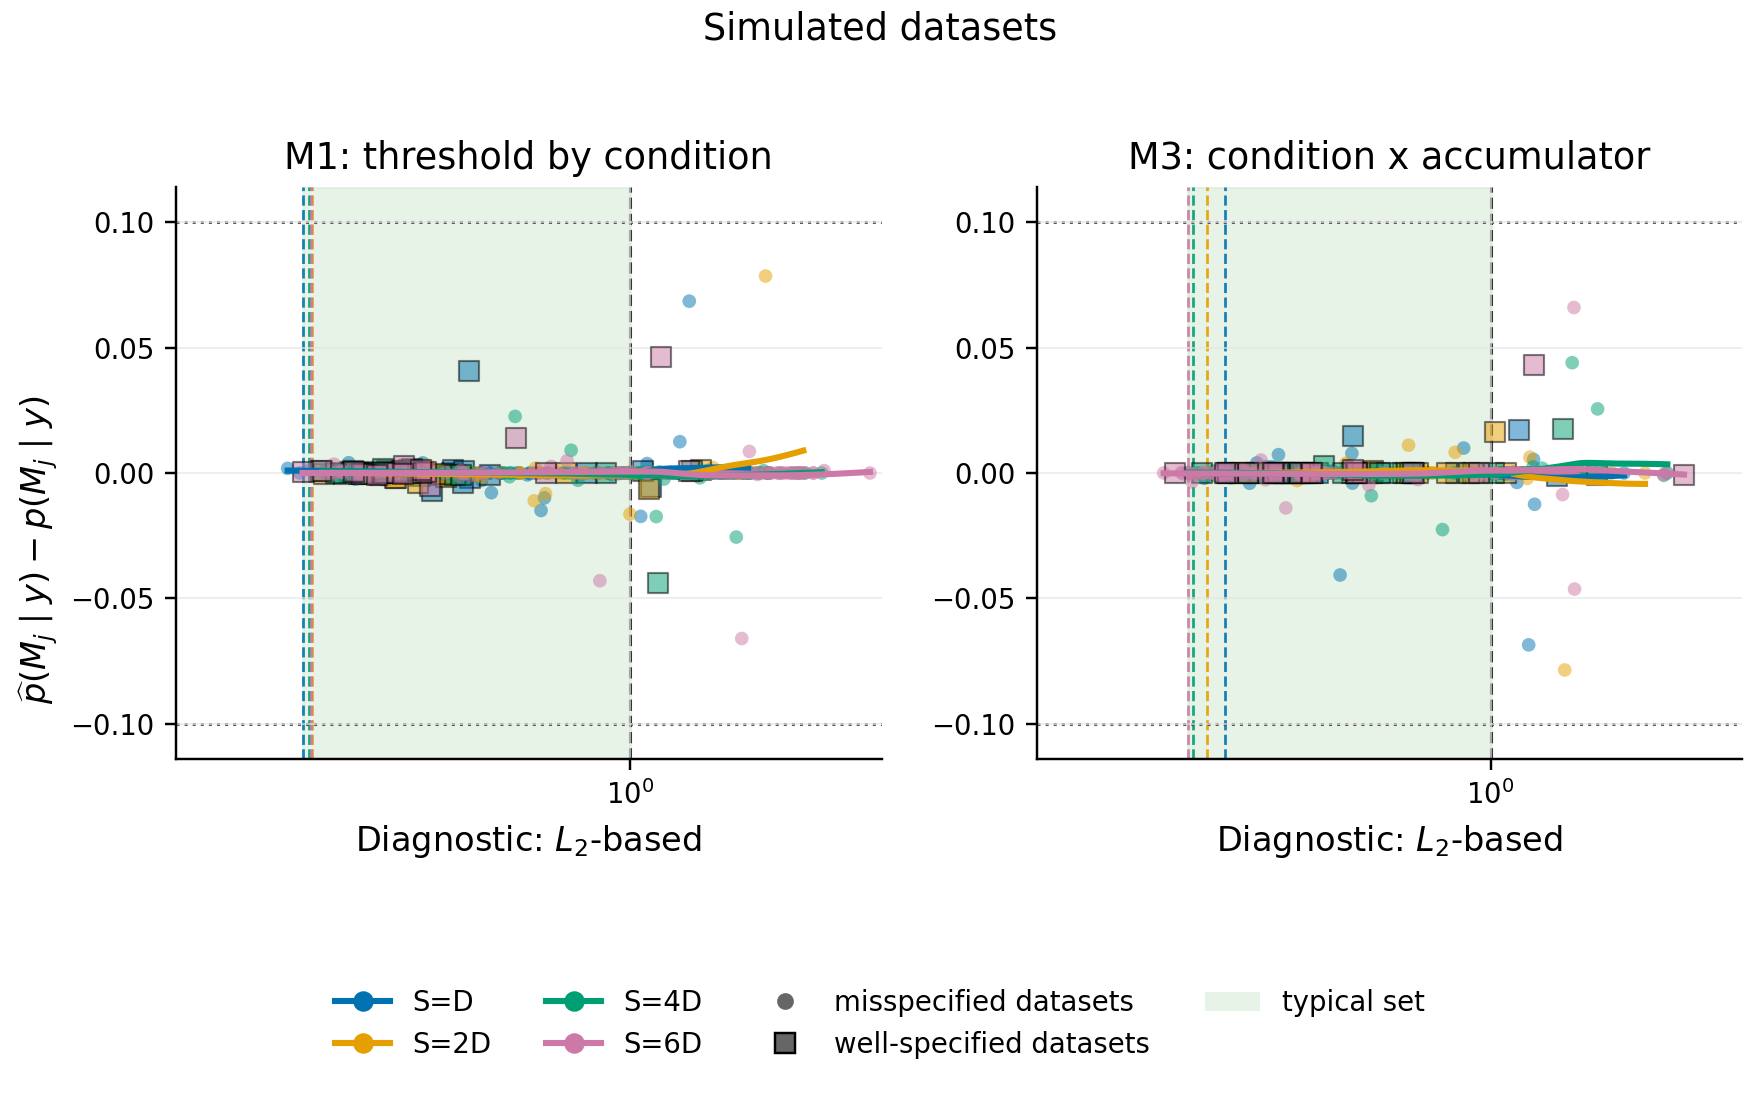

## Empirical datasets

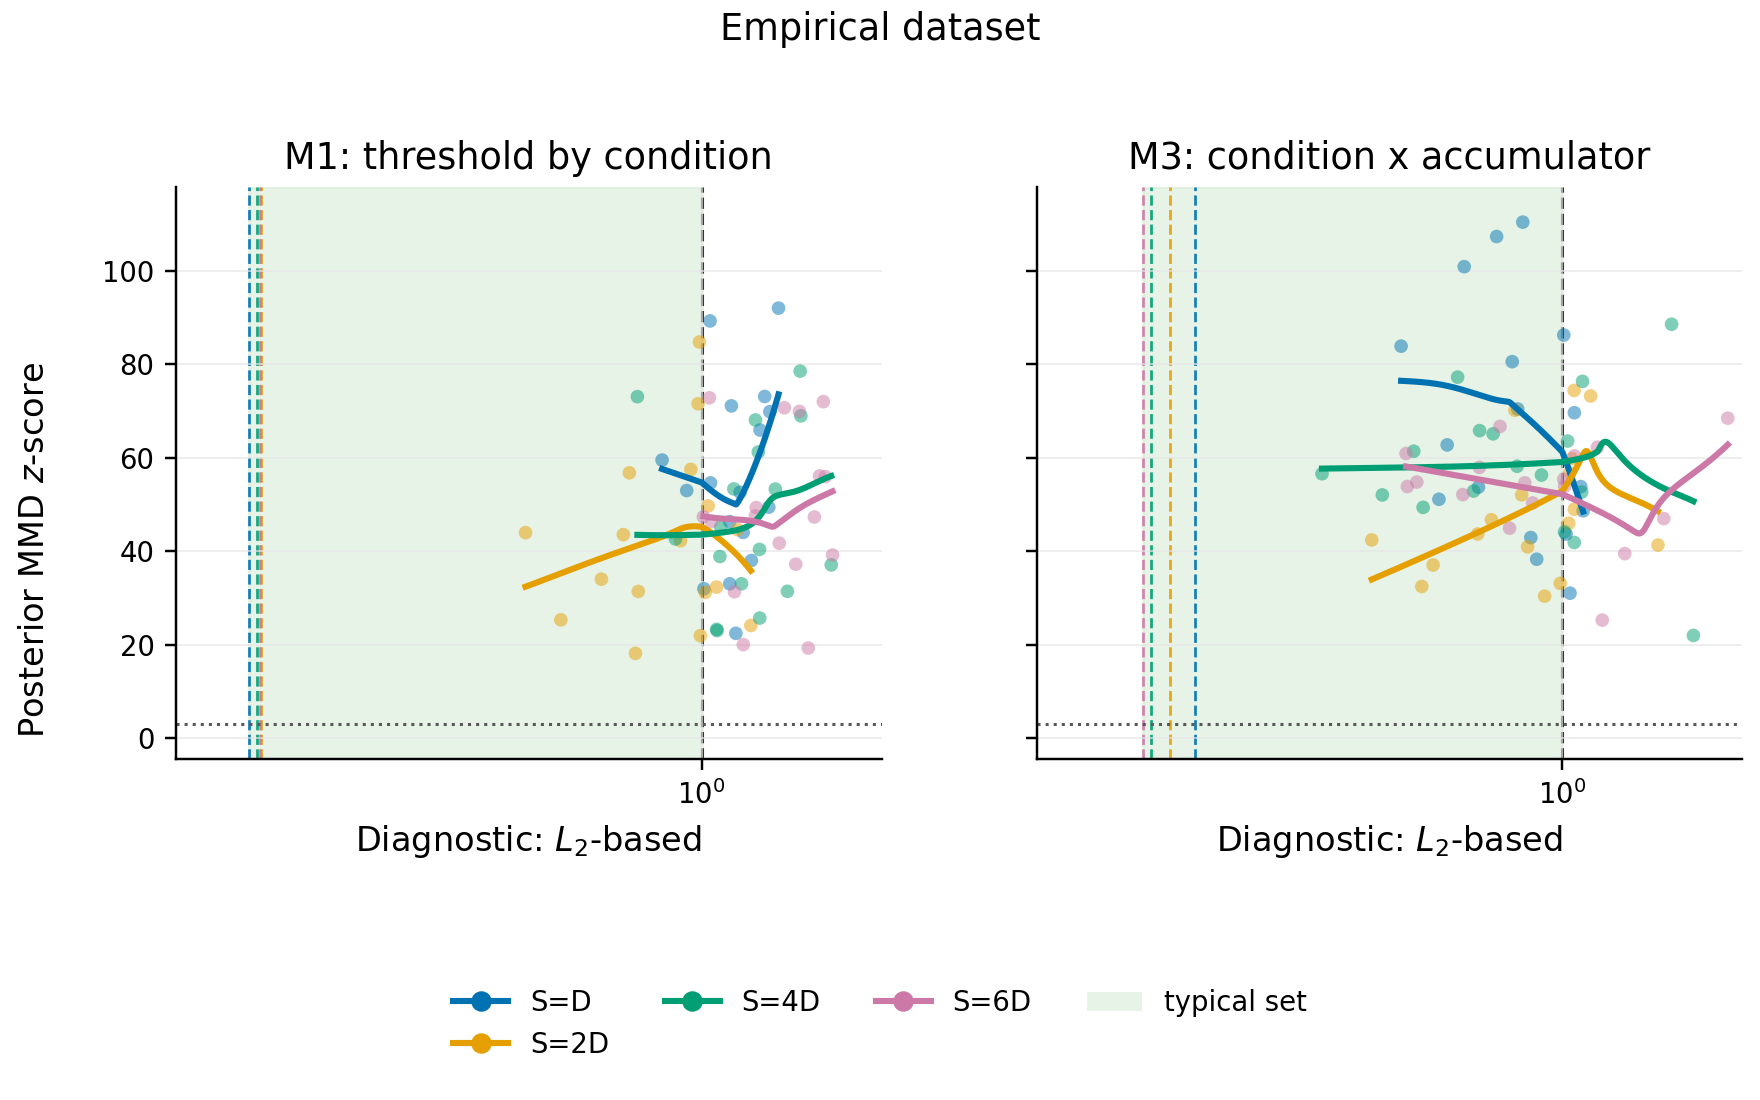

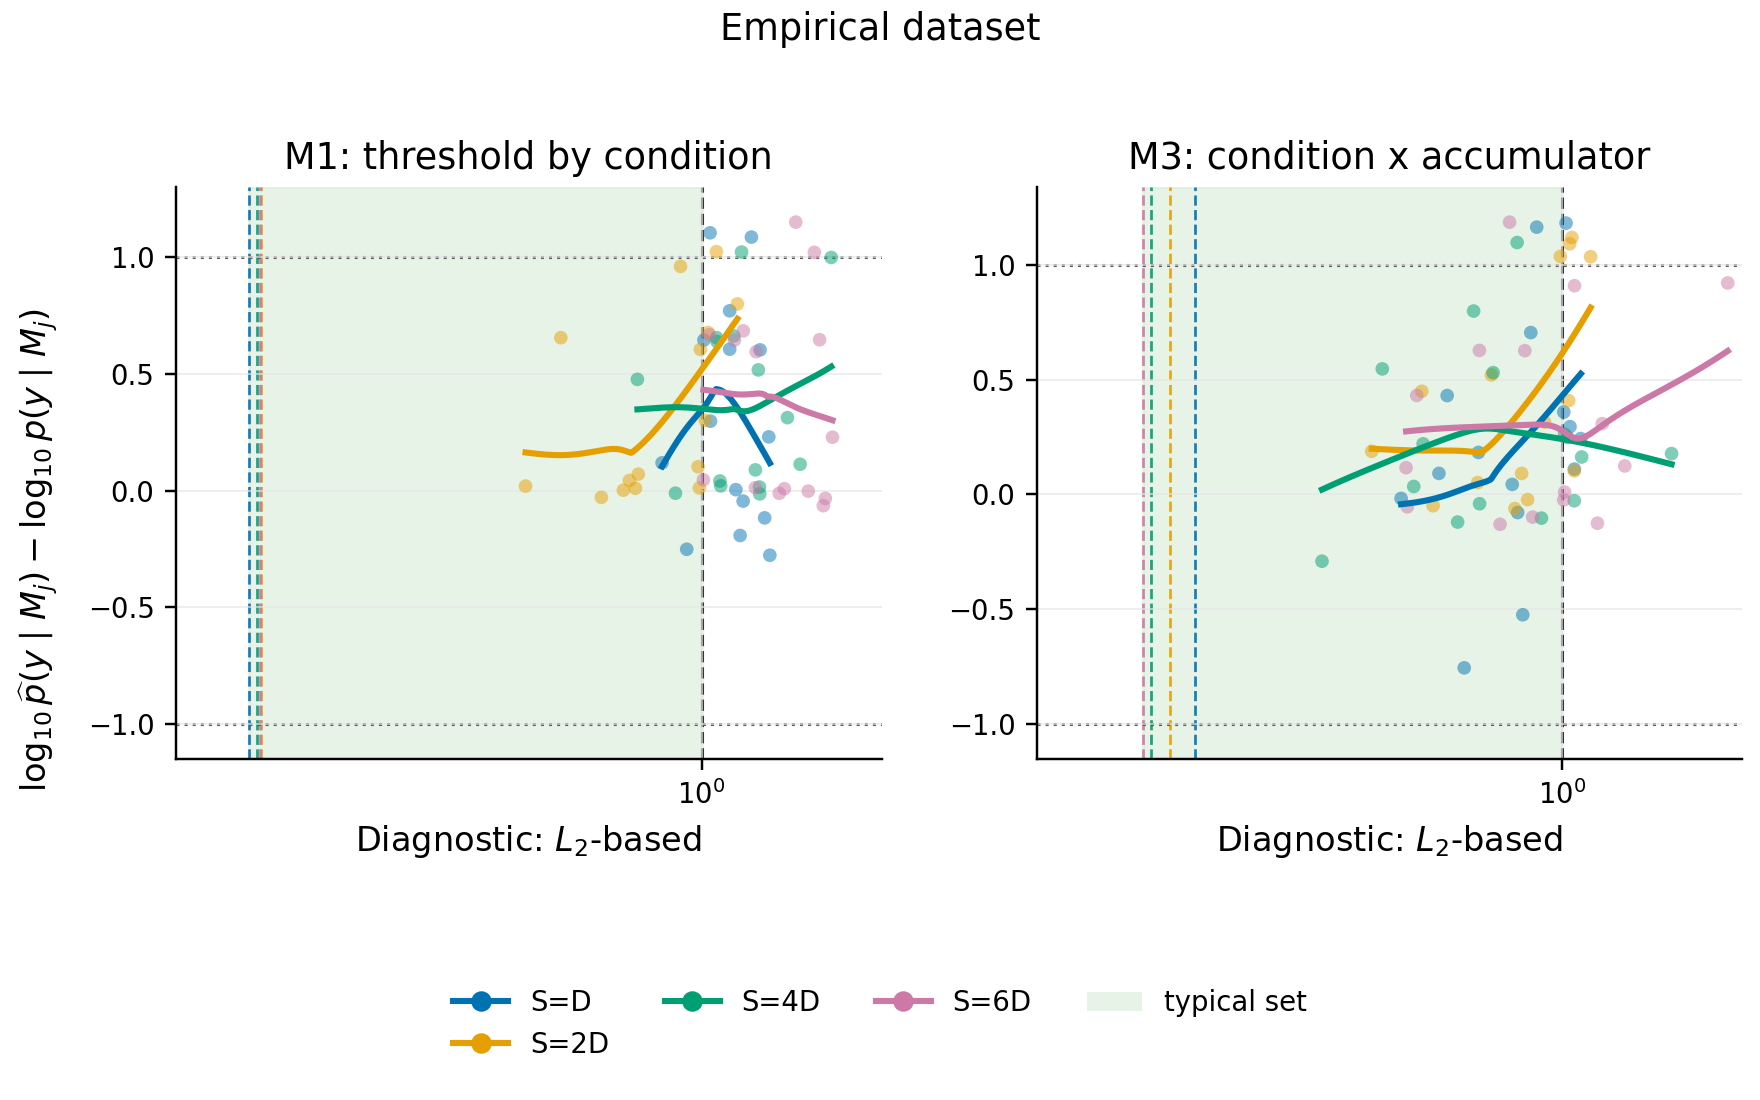

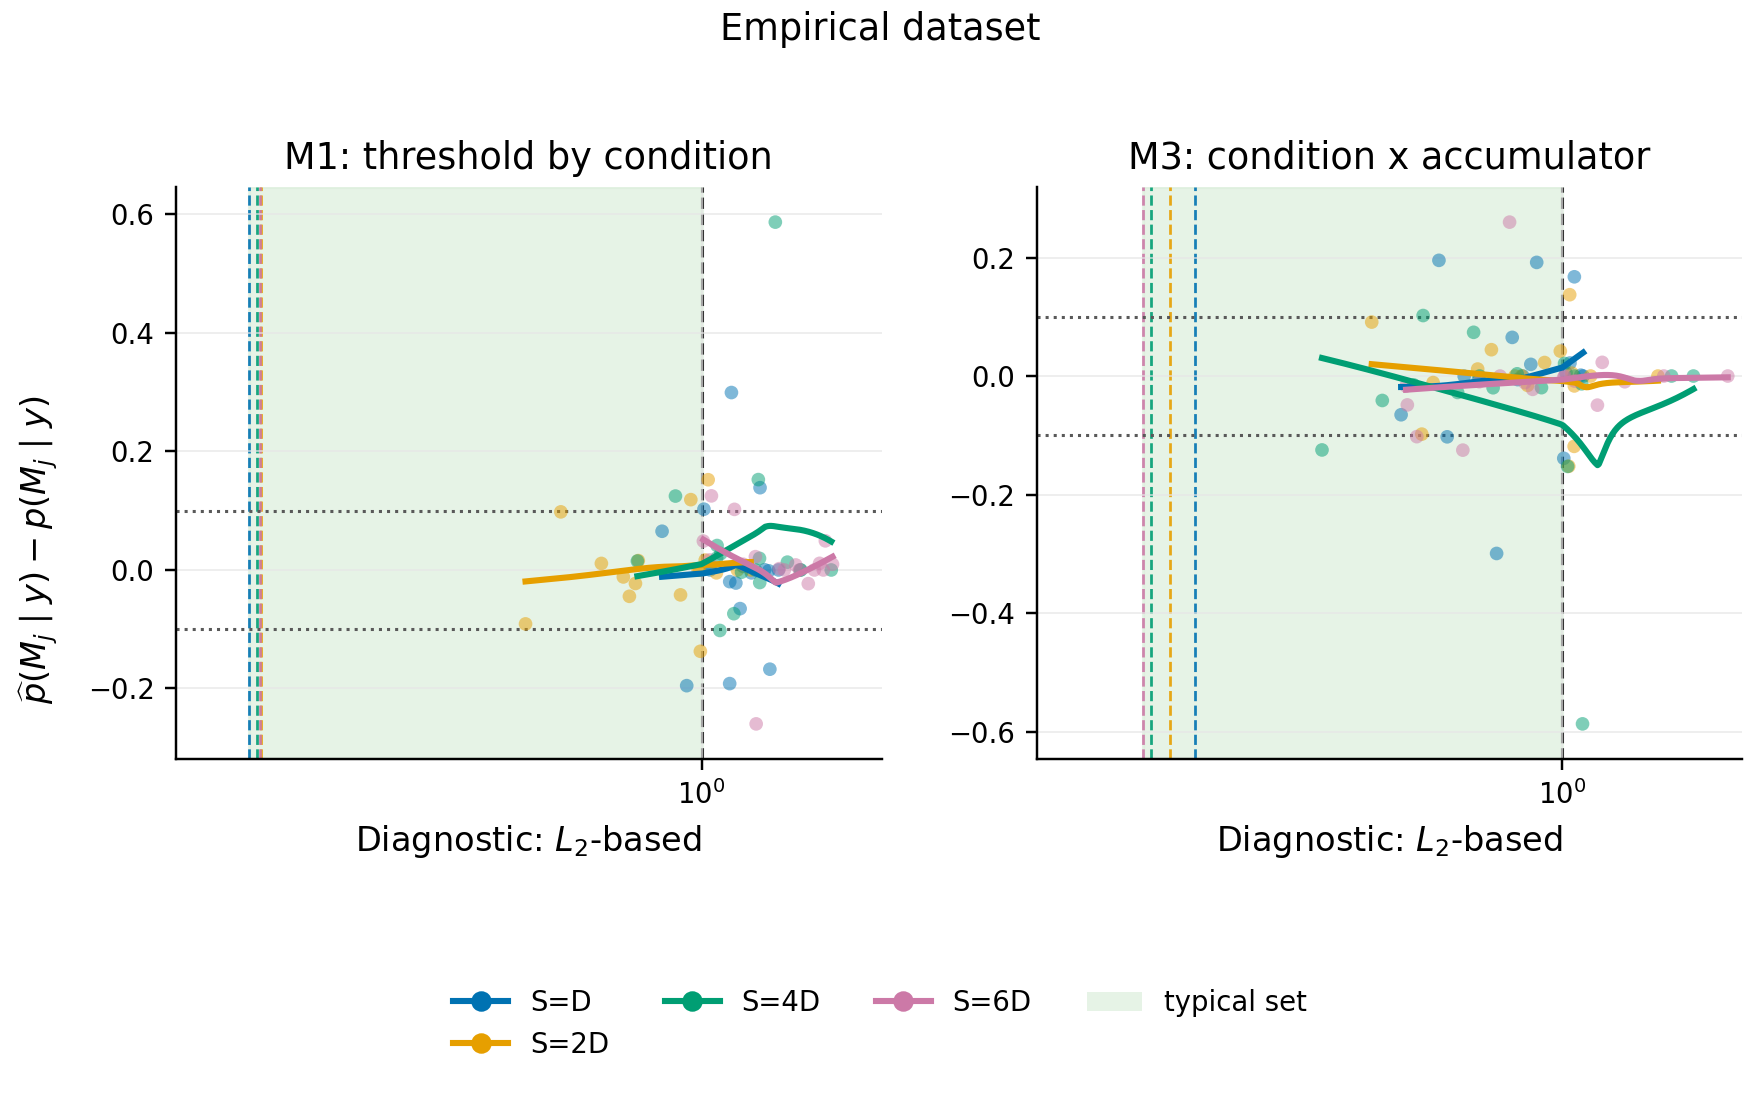

## Empirical PMP error vs. diagnostic $\rho$

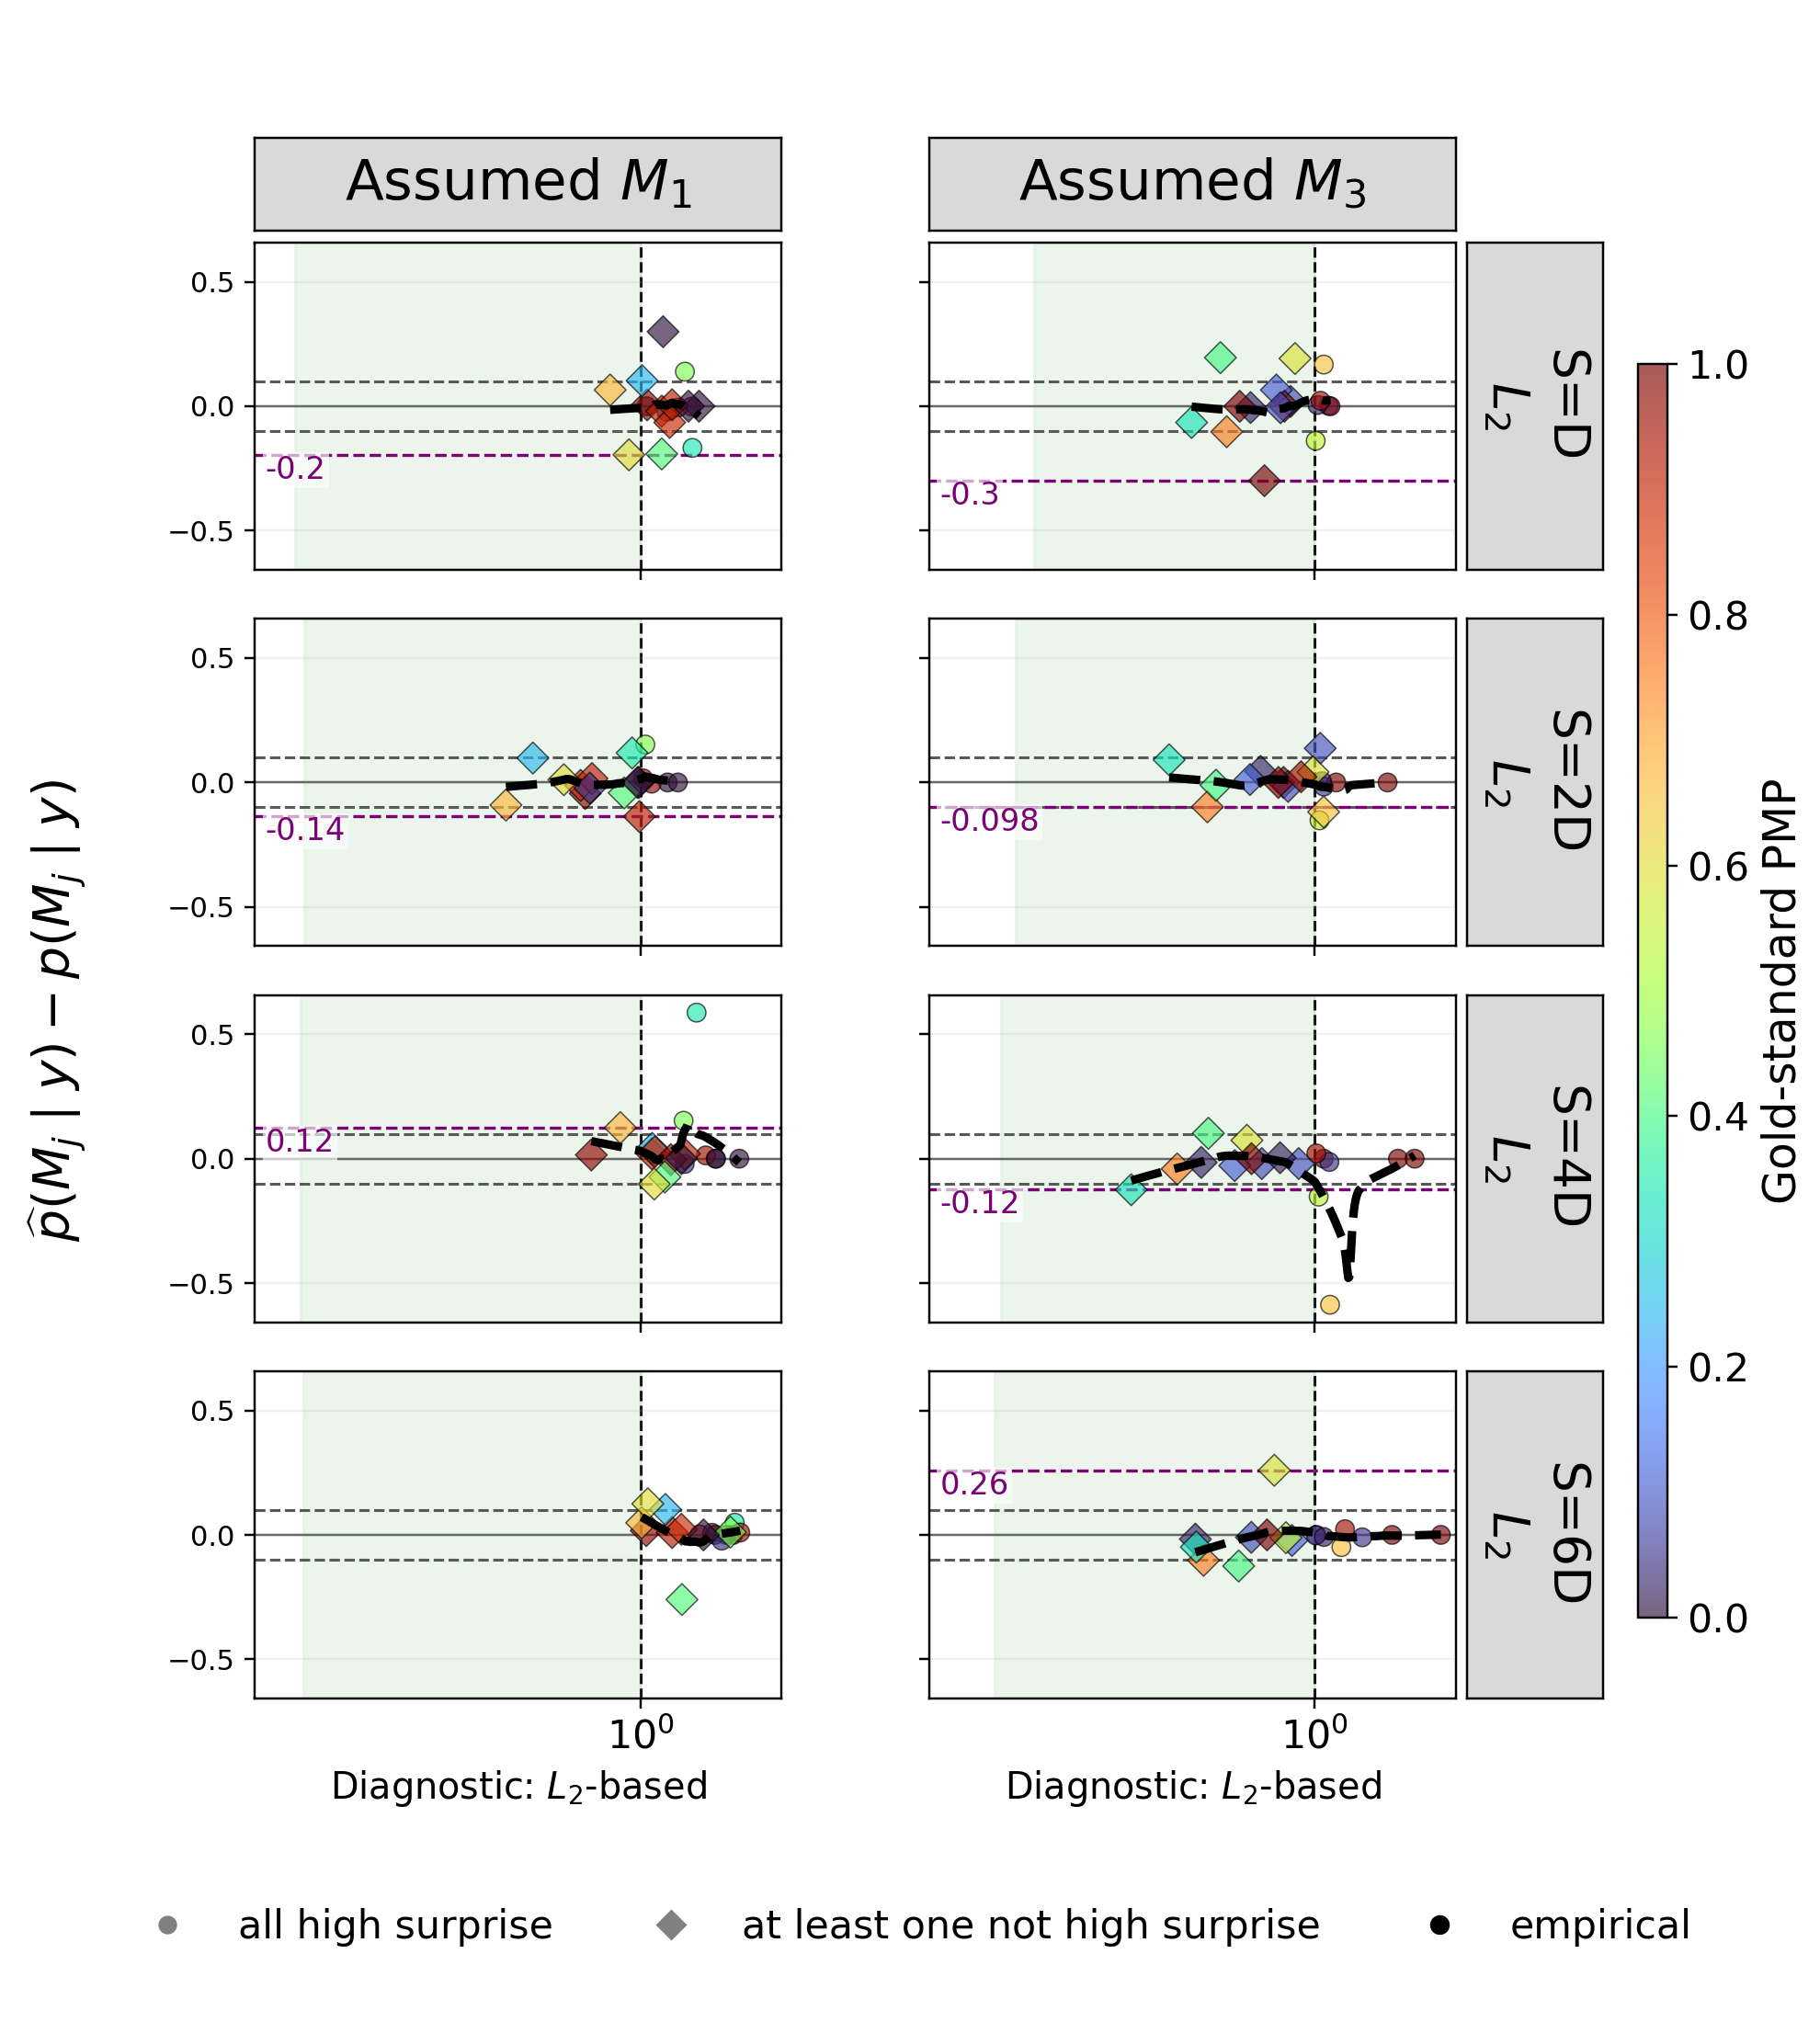

In [3]:
comparisons = run_comparison_pipeline(
    metrics=METRICS,
    model_sets=MODEL_SETS,
    summary_specs=RERUN_SUMMARY_SPECS,
    output_root=OUTPUT_ROOT,
)

for name, comparison in comparisons.items():
    print(name, comparison["output_root"])
    display_summary_dimension_comparison(comparison)

gold_pmp_paths = generate_gold_pmp_lowess_grid(
    METRICS[0], RERUN_VARIANT, output_root=OUTPUT_ROOT
)
display_gold_pmp_lowess_grid(gold_pmp_paths)
